<a href="https://colab.research.google.com/github/nm-razon/Pythone-Code/blob/main/Three_plot_together.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

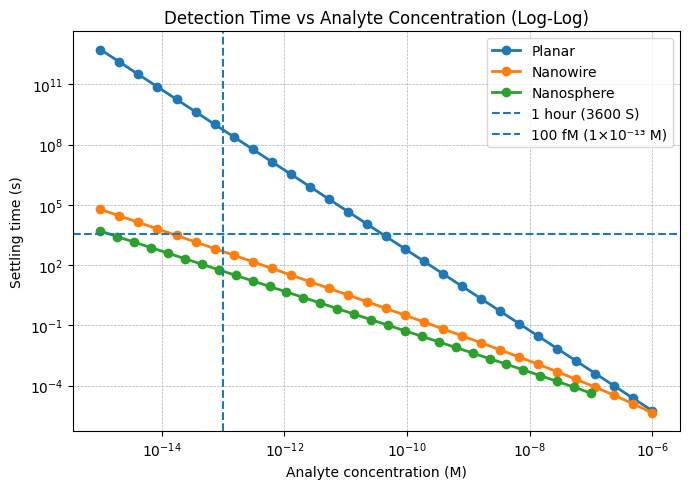

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== Change these filenames =====
files = {
    "Planar": "planar.txt",
    "Nanowire": "nanowire.txt",
    "Nanosphere": "nanosphere.txt"
}

plt.figure(figsize=(7, 5))

for label, filename in files.items():
    # Reads files even if they have header lines before the data
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if "," in line and not line.lower().startswith("analyte"):
                parts = line.split(",")
                try:
                    conc = float(parts[0])
                    time = float(parts[1])
                    data.append([conc, time])
                except ValueError:
                    pass

    df = pd.DataFrame(data, columns=["Concentration_M", "Settling_Time_s"])

    plt.loglog(
        df["Concentration_M"],
        df["Settling_Time_s"],
        marker="o",
        linewidth=2,
        label=label
    )

# Reference lines
plt.axhline(y=3600, linestyle="--", linewidth=1.5, label="1 hour (3600 S)")
plt.axvline(x=100e-15, linestyle="--", linewidth=1.5, label="100 fM (1×10⁻¹³ M)")

plt.xlabel("Analyte concentration (M)")
plt.ylabel("Settling time (s)")
plt.title("Detection Time vs Analyte Concentration (Log-Log)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("biosensor_detection_limit_plot.png", dpi=300)
plt.show()